# K-Means Algorithm

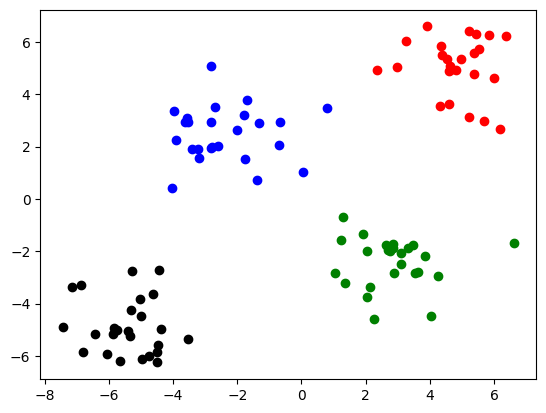

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_blobs

class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        #Step 1: Decide Number of Clusters
        self.n_clusters=n_clusters
        self.max_iter=max_iter
        self.centroids=None

    def fit_predict(self,X):
        #Step2: Select random centroids
        random_index=random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids=X[random_index]

        #Step 3:
        for i in range(self.max_iter):
        #i. Assign clusters
            cluster_group=self.assign_clusters(X)
        #ii. Moving centroids
            old_centroids=self.centroids
            self.centroids=self.move_centroids(X,cluster_group)
        #iii.Check finish
            if(old_centroids==self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self, X):
        cluster_group=[]
        distances=[]

        #Finds each row's distance from each clusters, 100 points->100*2(centroids) distances
        for row in X: #Runs 100 times
            for centroid in self.centroids: #Runs 2 times
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distance=min(distances)
            index_pos=distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()
                                
        return np.array(cluster_group)

    def move_centroids(self,X,cluster_group):
        #Segregate and calculate mean for all 0 and 1 points
        new_centroids=[]

        cluster_type=np.unique(cluster_group)

        for type in cluster_type:
            new_centroids.append(X[cluster_group==type].mean(axis=0))

        return np.array(new_centroids)

        
        
        
centroids=[(-5,-5),(5,5),(-2.5,2.5),(2.5,-2.5)]
cluster_std=[1,1,1,1]
X,y=make_blobs(n_samples=100,
               cluster_std=cluster_std,
               centers=centroids,
               n_features=2,
               random_state=2)

km=KMeans(n_clusters=4,max_iter=100)
y_means=km.fit_predict(X)
plt.scatter(X[y_means==0,0],X[y_means==0,1],color='red')
plt.scatter(X[y_means==1,0],X[y_means==1,1],color='blue')
plt.scatter(X[y_means==2,0],X[y_means==2,1],color='black')
plt.scatter(X[y_means==3,0],X[y_means==3,1],color='green')
plt.show()